# Block 2 · Week 1 — Calculus Foundations
## Limits, Derivatives & the Rules of Differentiation (single variable)

This notebook consolidates Week 1 of Block 2 (Calculus & Gradients). The arc of the
week: **limits** define the **derivative**, and the **rules of differentiation** turn
that definition into fast, reusable tools — the machinery a model uses to learn.

**Topics covered**
1. Limits & continuity — what "approaching a point" means
2. Derivatives from the definition — slope at a single point, as a limit
3. Rules of differentiation — power, constant, sum, product, quotient
4. Apply — differentiating a loss function (the heart of gradient descent)

**Approach:** each concept is introduced with intuition, verified in code
(numerically and, for the rules, symbolically), and tied to a real ML use.

## 1. Limits & Continuity

A **limit** is the value a function heads toward as the input gets arbitrarily close
to a point — even if the function is undefined *at* that point. It cares about where
the function is *heading*, not whether it arrives.

Anchor example:

$$f(x) = \frac{x^2 - 1}{x - 1}$$

At $x = 1$ this is $0/0$ — a **hole**. But factoring gives $x^2-1=(x-1)(x+1)$, so away
from the hole $f(x)=x+1$, which heads to $2$:

$$\lim_{x \to 1}\frac{x^2-1}{x-1} = 2$$

**Existence rule (one-sided limits):** the two-sided limit exists only if the left and
right limits are *equal*. If they disagree, the limit **does not exist (DNE)** — this
is the kind of "kink" that later makes a function non-differentiable.

In [1]:
import numpy as np

# A limit that EXISTS: both sides approach 2 (we never evaluate AT x = 1, the hole)
f = lambda x: (x**2 - 1) / (x - 1)
left  = np.array([0.9, 0.99, 0.999, 0.9999])
right = np.array([1.1, 1.01, 1.001, 1.0001])
print("f(x) = (x^2 - 1)/(x - 1)   as x -> 1")
print("  from left: ", f(left))
print("  from right:", f(right), "\n")

# A limit that does NOT exist: the two sides disagree (a jump)
g = lambda x: np.abs(x) / x
print("g(x) = |x|/x   as x -> 0")
print("  from left: ", g(np.array([-0.1, -0.01, -0.001])), "-> -1")
print("  from right:", g(np.array([ 0.1,  0.01,  0.001])), "-> +1")
print("  left != right  =>  two-sided limit DNE")

f(x) = (x^2 - 1)/(x - 1)   as x -> 1
  from left:  [1.9    1.99   1.999  1.9999]
  from right: [2.1    2.01   2.001  2.0001] 

g(x) = |x|/x   as x -> 0
  from left:  [-1. -1. -1.] -> -1
  from right: [1. 1. 1.] -> +1
  left != right  =>  two-sided limit DNE


## 2. Derivatives from the Definition

A **derivative** is the slope of a function at a single point. Slope needs two points
($x$ and $x+h$), so we take the slope of the **secant** line and shrink the gap $h$ to
zero — the secant pivots into the **tangent**. That limit *is* the derivative:

$$f'(x) = \lim_{h \to 0}\frac{f(x+h) - f(x)}{h}$$

Worked example ($f(x)=x^2$): expanding and cancelling the $h$ gives
$\lim_{h\to0}(2x+h) = 2x$. The key discipline: never plug $h=0$ early — simplify until
$h$ cancels, *then* take the limit.

Below we verify this numerically for $f(x)=x^2+3x$ (hand-derivative $2x+3$, so $f'(2)=7$)
and plot the tangent line so the slope is visible.

numerical f'(2) = 7.000000081802682  (hand: 7)


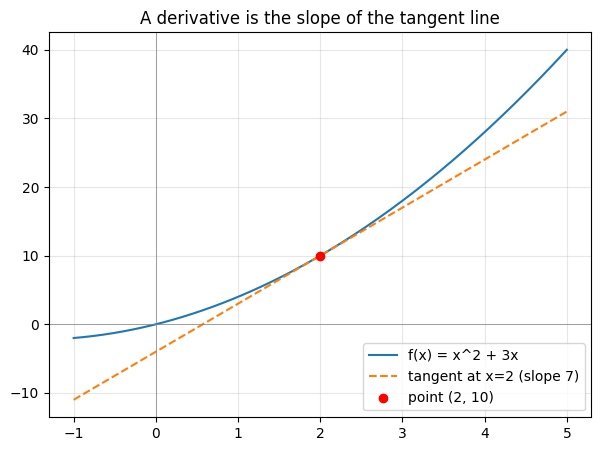

In [2]:
import matplotlib.pyplot as plt

def numerical_derivative(fn, x, h=1e-7):
    return (fn(x + h) - fn(x)) / h          # the definition, minus the limit

fp = lambda x: x**2 + 3*x                    # f'(x) = 2x + 3  ->  f'(2) = 7
print("numerical f'(2) =", numerical_derivative(fp, 2.0), " (hand: 7)")

# plot the tangent at x = 2: a line touching the curve, slope 7
a = 2.0
fa = fp(a)
slope = 2*a + 3
xs = np.linspace(-1, 5, 200)
plt.figure(figsize=(7, 5))
plt.plot(xs, fp(xs), label="f(x) = x^2 + 3x")
plt.plot(xs, fa + slope*(xs - a), "--", label=f"tangent at x={a:.0f} (slope {slope:.0f})")
plt.scatter([a], [fa], color="red", zorder=5, label=f"point ({a:.0f}, {fa:.0f})")
plt.axhline(0, color="gray", lw=0.5); plt.axvline(0, color="gray", lw=0.5)
plt.title("A derivative is the slope of the tangent line")
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

## 3. Rules of Differentiation

Computing every derivative from the definition is slow. These **rules** give the answer
instantly — each is the limit above, *pre-solved* once for the general case, so they're
trustworthy universal tools.

| Rule | Statement |
|---|---|
| Power | $\frac{d}{dx}x^n = n\,x^{n-1}$ |
| Constant | $\frac{d}{dx}[c] = 0$ |
| Constant multiple | $\frac{d}{dx}[c\,f] = c\,f'$ |
| Sum / difference | $\frac{d}{dx}[f \pm g] = f' \pm g'$ |
| Product | $\frac{d}{dx}[f\,g] = f'g + fg'$  (**not** $f'g'$) |
| Quotient | $\frac{d}{dx}\!\left[\frac{f}{g}\right] = \frac{f'g - fg'}{g^2}$ |

That the power rule is the limit pre-solved is easy to see for $x^3$: expanding
$(x+h)^3$, only the $3x^2h$ term survives after dividing by $h$ and sending $h\to0$,
leaving $3x^2 = n\,x^{n-1}$.

We verify three hand-derivatives two independent ways — **numerically** (slope at a
point) and **symbolically** with SymPy (the whole formula). SymPy works with math
*symbols* rather than numbers, so it confirms the entire expression, not just one point;
it's an answer key, not how real ML differentiates (that's automatic differentiation,
coming in Week 2).

In [3]:
import sympy as sp

# hand-derivatives from the paper step:
#   (c) 3x^2 + 2x - 7   ->  6x + 2
#   (d) x^2 * x^3       ->  5x^4        (product rule; check vs power rule on x^5)
#   (e) x^2 / (x+1)     ->  (x^2 + 2x)/(x+1)^2   (quotient rule)
cases = {
    "(c) 3x^2 + 2x - 7": (lambda x: 3*x**2 + 2*x - 7, lambda x: 6*x + 2),
    "(d) x^2 * x^3":     (lambda x: (x**2)*(x**3),    lambda x: 5*x**4),
    "(e) x^2 / (x+1)":   (lambda x: x**2/(x + 1),     lambda x: (x**2 + 2*x)/(x + 1)**2),
}
print("Numerical check at x = 4 (numerical vs hand):")
for name, (fn, hand) in cases.items():
    print(f"  {name:20s} {numerical_derivative(fn, 4.0):>12.5f}  vs  {hand(4.0):.5f}")

print("\nSymbolic check with SymPy (the full formula):")
x = sp.symbols('x')
for label, expr in {"(c)": 3*x**2 + 2*x - 7, "(d)": (x**2)*(x**3), "(e)": x**2/(x + 1)}.items():
    print(f"  {label} d/dx =", sp.simplify(sp.diff(expr, x)))

Numerical check at x = 4 (numerical vs hand):
  (c) 3x^2 + 2x - 7        26.00000  vs  26.00000
  (d) x^2 * x^3          1280.00007  vs  1280.00000
  (e) x^2 / (x+1)           0.96000  vs  0.96000

Symbolic check with SymPy (the full formula):
  (c) d/dx = 6*x + 2
  (d) d/dx = 5*x**4
  (e) d/dx = x*(x + 2)/(x**2 + 2*x + 1)


## 4. Apply — Differentiating a Loss Function

This is the payoff: the rules above are what lets a model **learn**. (Concept only — no
code; this is the reasoning that connects derivatives to gradient descent.)

A model guesses $\hat{y} = w\,x$, where $x$ is the input and $w$ is a "dial" (weight) it
can turn. The truth is $y$. We measure how wrong the guess is with the **squared-error
loss** (squared so over/under-predictions don't cancel, and big errors are punished more):

$$L(w) = (wx - y)^2$$

Here $x, y$ are fixed data; $w$ is the only thing training changes, so we differentiate
w.r.t. $w$. Expanding first (to avoid the chain rule, which comes in Week 2) and applying
the constant-multiple, power, and sum rules:

$$L(w) = w^2x^2 - 2xy\,w + y^2 \;\;\Longrightarrow\;\; \frac{dL}{dw} = 2x^2w - 2xy = 2x(\hat{y} - y)$$

The slope is **proportional to the error** $(\hat{y}-y)$:

- perfect guess $\Rightarrow$ error $0$ $\Rightarrow$ slope $0$ $\Rightarrow$ dial doesn't move (at the minimum);
- guess too high $\Rightarrow$ slope positive $\Rightarrow$ step $w$ **down**;
- guess too low $\Rightarrow$ slope negative $\Rightarrow$ step $w$ **up**;
- bigger error $\Rightarrow$ bigger step.

That is the "step opposite the slope" loop from Day 2 — and the slope came straight from
this week's rules. This derivative, $2x(\hat{y}-y)$, is the heart of how linear regression
trains, and gets built in the Phase 1 capstone.

## Reflection — Week 1 (Block 2)

The week built one clean chain: a **limit** makes "slope at a single point" well-defined,
that slope *is* the **derivative**, and the **rules** are that derivative pre-solved so we
can compute fast. The most useful shift was seeing derivatives not as an abstract exercise
but as the exact thing that tells a model which way to nudge its parameters — the gradient
of a loss is proportional to the error the model just made.

One honest limitation carried through: expanding $(wx-y)^2$ by hand only works because it's
a simple squared term. Real models nest many functions, and the **chain rule** (Week 2) is
the tool that handles that nesting cleanly.

**Next — Week 2 (multivariable):** partial derivatives, gradients, the chain rule, and
gradient descent itself — where these single-variable ideas generalise to the many-parameter
setting real models live in.